# Tutorial 2: AR(p), MA(q), ARMA(p,q) Models
**Empirical exercise**

The data set `cpi.csv` contains monthly data on the US consumer price index, from January 1983 to December 2018.

### Import packages, data and set plot style

In [15]:
%reset -f

import pandas            as pd
import matplotlib.pyplot as plt
import statsmodels.api   as sm
import seaborn           as sns
import numpy             as np

from datetime                    import datetime
from statsmodels.tsa.stattools   import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

In [16]:
# set plot
sns.set_style('darkgrid')
pd.plotting.register_matplotlib_converters()
# Default figure size
sns.mpl.rc('figure',figsize=(16, 6))
pd.set_option('display.float_format', lambda x: '%.2f' % x) # makes numbers nice

In [17]:
#import data
df = pd.read_csv('cpi.csv')

In [18]:
df.head()

,month,CPI
0,Jan 1983,97.9
1,Feb 1983,98.0
2,Mar 1983,98.1
3,Apr 1983,98.8
4,May 1983,99.2


In [19]:
df.tail()

,month,CPI
427,Aug 2018,251.879
428,Sep 2018,252.010
429,Oct 2018,252.794
430,Nov 2018,252.760
431,Dec 2018,252.723


### Plots & ACF Plots for CPI
**(a) Plot the autocorrelation function of the CPI, and give brief comments about the ACF.**

We observe extremely high autocorrelations for a very long time – even at a three-year horizon correlations around 0.7 are found. This does not seem like an interesting series to analyze or forecast directly; it will be hard to find a model that provides better forecasts than ŷt+1 = yt , plus maybe some small constant to take care of the trend.

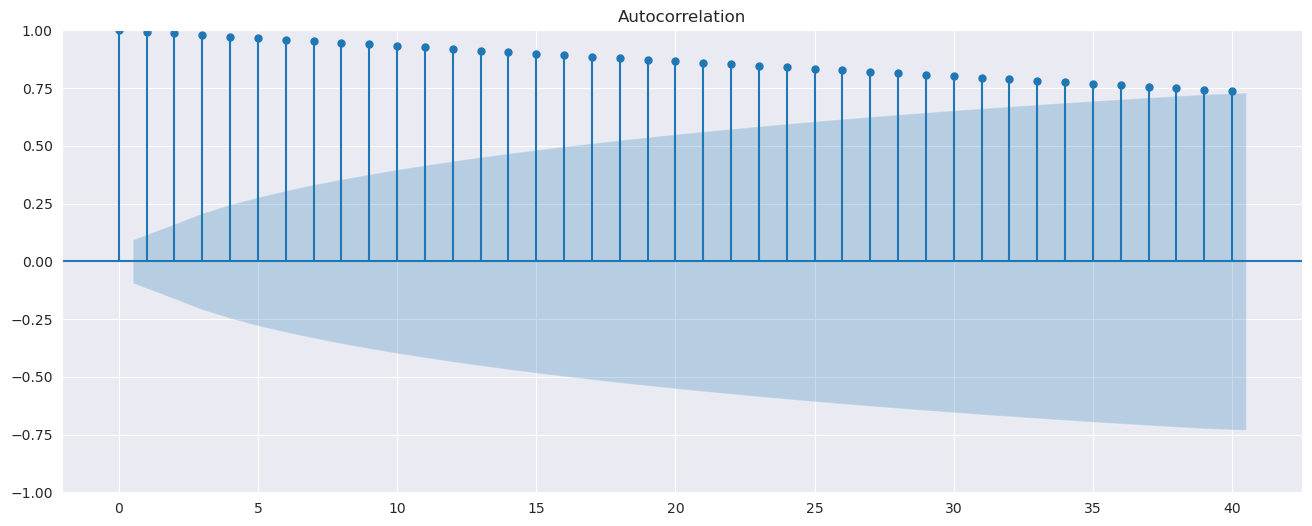

In [20]:
sm.graphics.tsa.plot_acf(df['CPI'].values.squeeze(), lags = 40)
plt.show()

**(b) Draw a time series graph of CPI. Does the series look stationary? How does this relate to your result in part (a)?**

That’s a pretty clear trend, so a stationarity assumption would be unrealistic. This means that we shouldn’t really trust the autocorrelation function from part(a), since we’ve estimated something that doesn’t even exist in the population.

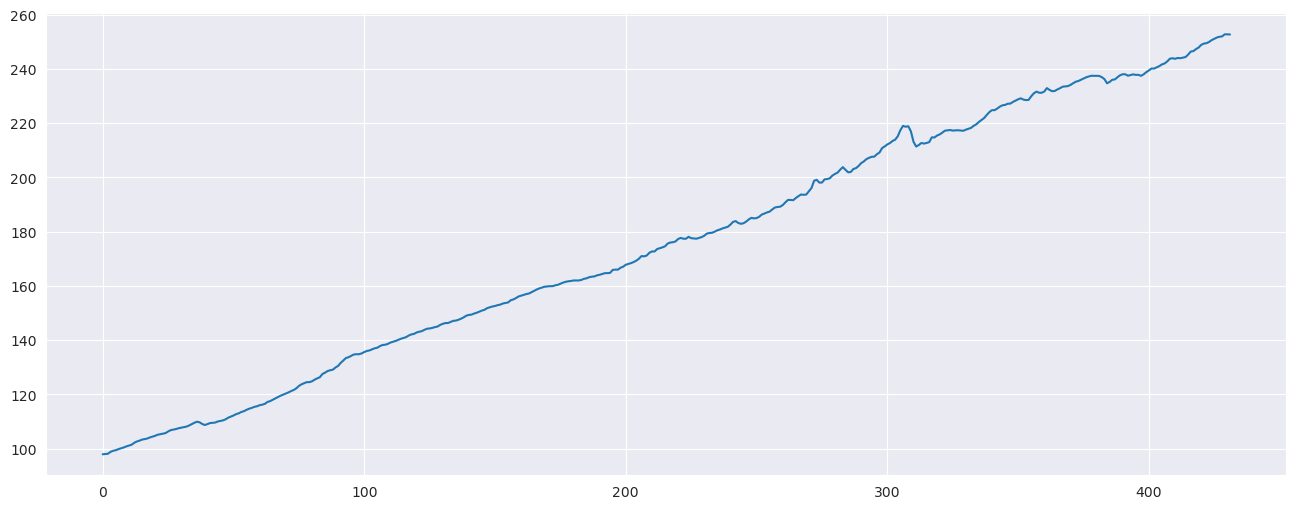

In [21]:
df['CPI'].plot()
plt.show()

### Calculate Inflation Variables
**(c) Construct a new time series that measures year-on-year inflation. Does this series look stationary?**

This time series definitely looks much more like a stationary series. We will discuss statistical tests for stationarity later on.

In [22]:
df['infl'] = df['CPI'].diff(periods = 12) / df['CPI'].shift(12)

In [23]:
df.head(13)

,month,CPI,infl
0,Jan 1983,97.9,NaN
1,Feb 1983,98.0,NaN
2,Mar 1983,98.1,NaN
3,Apr 1983,98.8,NaN
4,May 1983,99.2,NaN
5,Jun 1983,99.4,NaN
6,Jul 1983,99.8,NaN
7,Aug 1983,100.1,NaN
8,Sep 1983,100.4,NaN
9,Oct 1983,100.8,NaN


In [24]:
df.tail(12)

,month,CPI,infl
420,Jan 2018,248.884,0.020937
421,Feb 2018,249.369,0.022167
422,Mar 2018,249.498,0.023586
423,Apr 2018,249.956,0.024196
424,May 2018,250.646,0.027398
425,Jun 2018,251.134,0.028471
426,Jul 2018,251.597,0.029490
427,Aug 2018,251.879,0.026833
428,Sep 2018,252.010,0.022693
429,Oct 2018,252.794,0.025172


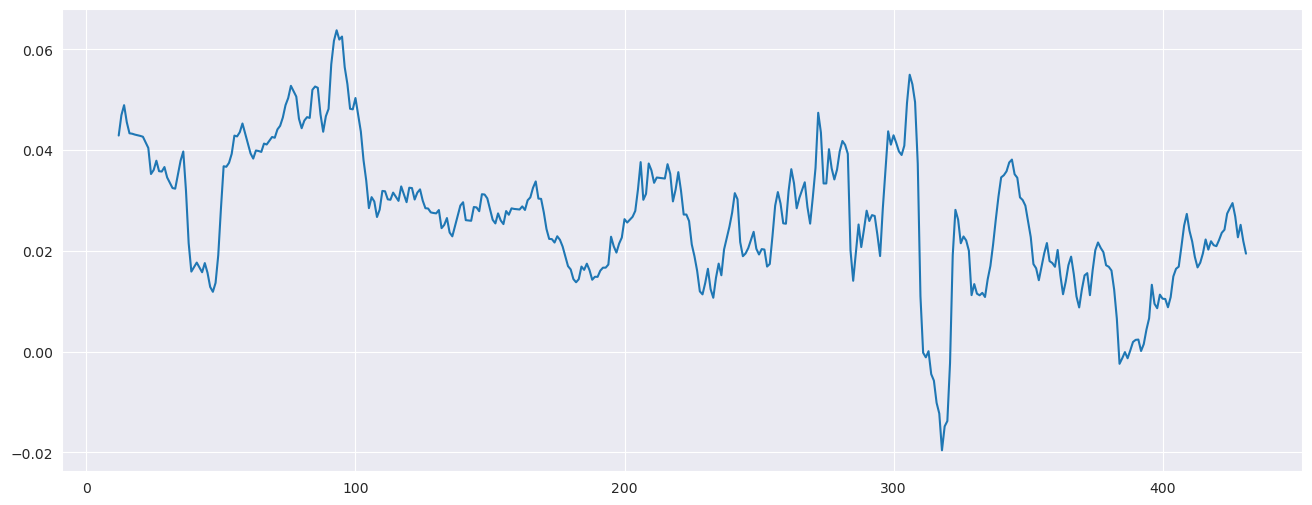

In [25]:
df['infl'].plot()
plt.show()

**(d) Plot the autocorrelation function of inflation, You may include more than the default of forty lags.). Is a cyclical pattern visible?**

The autocorrelations decay much more quickly than they do for the CPI series, which means that there is a potentially interesting forecasting task here. Also, a cyclical pattern is apparent, as expected, although it’s not very strong in this particular data set.

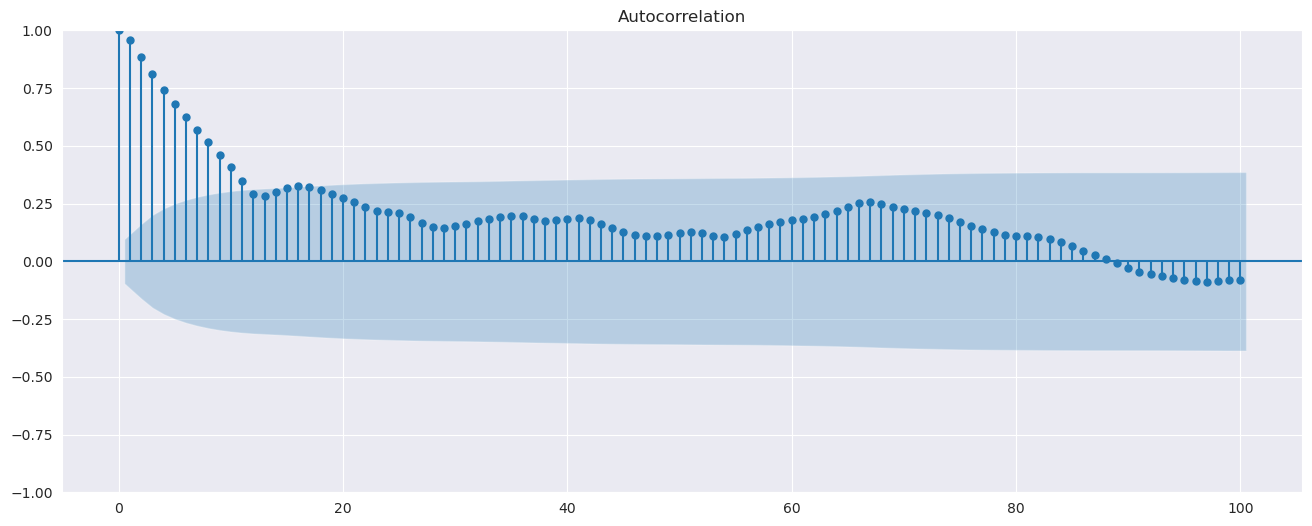

In [26]:
sm.graphics.tsa.plot_acf(df['infl'].dropna().values.squeeze(), lags = 100)
plt.show()

**(e) Is a seasonal pattern visible?**

Yes, there appears to be quite an obvious seasonal element.

In [35]:
df['month'] = pd.to_datetime(df['month'])

/tmp/ipykernel_93050/1100761606.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['month'] = pd.to_datetime(df['month'])


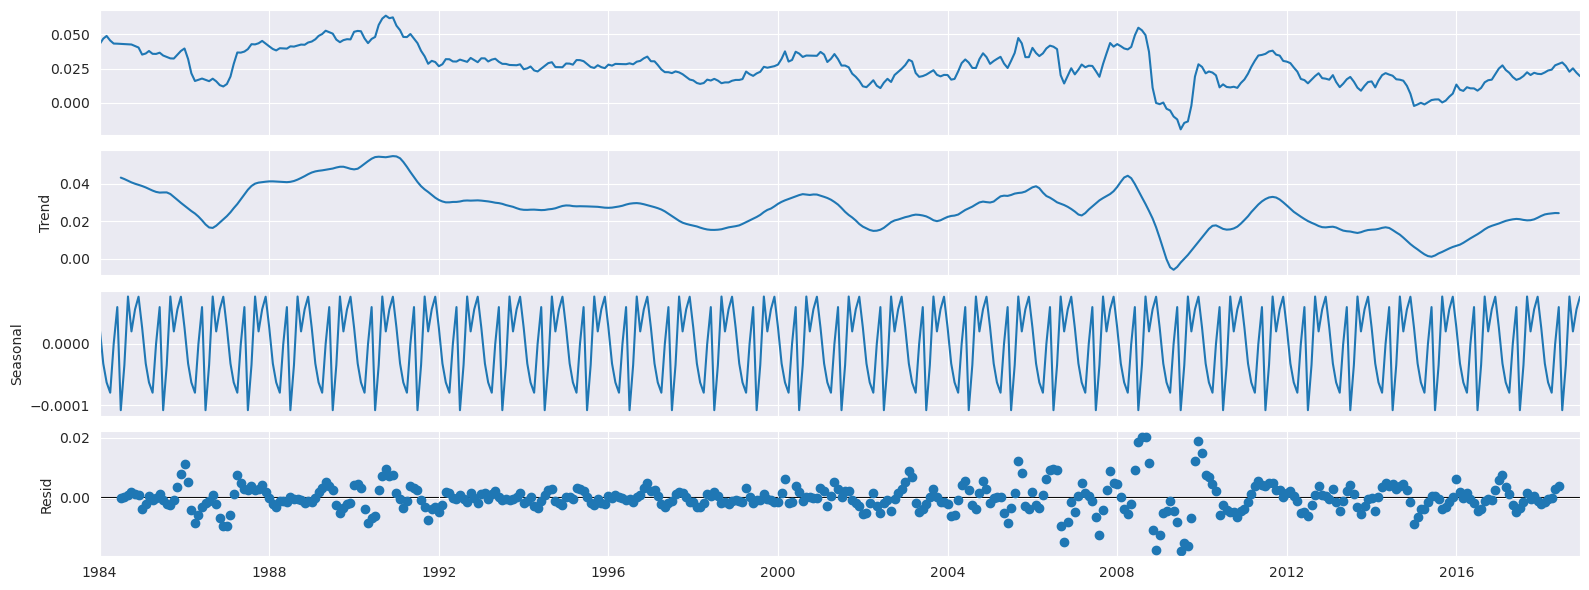

In [46]:
decomp = seasonal_decompose(df[['month','infl']].set_index('month').dropna(), model = "additive", period = 12)

decomp.plot();